# Digits Classification With Learned Superposition Activations

This notebook moves the superposition-activation classifier to the sklearn Digits dataset. To keep the run reproducible and runtime reasonable, the input features are standardized and then compressed with PCA before any baseline or quantum model is trained.

In [1]:
import sys
from pathlib import Path

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "qfun").is_dir():
        _root = str(_p.resolve())
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break

from qfun.datasets import load_classification_dataset, prepare_classification_split
from qfun.qfan._classification_benchmarks import (
    build_comparison_rows,
    display_baseline_suite,
    display_quantum_result,
    print_comparison_table,
    print_split_summary,
    plot_training_diagnostics,
    run_default_baseline_suite,
    run_quantum_experiment,
)

## Config

The Digits defaults use PCA-compressed inputs and a slightly larger hidden layer than the smaller tabular datasets.

In [2]:
data_seed = 7
test_size = 0.25
pca_components = 16

hidden_units = 6
n_qubits = 3
steps = 20
learning_rate = 0.04
log_every = 5
snapshot_interval = 5
eval_shots = 3_000

## 1. Load, Standardize, And Compress Digits

The dataset is standardized first, then projected down to 16 principal components before training. The quantum activations therefore act on a classifier fed by PCA-compressed features rather than the original 64-pixel vectors.

In [3]:
digits_dataset = load_classification_dataset("digits")
digits_split = prepare_classification_split(
    digits_dataset,
    test_size=test_size,
    seed=data_seed,
    standardize=True,
    pca_components=pca_components,
)
class_names = digits_split.target_names
print_split_summary(digits_dataset.name, digits_split)

Dataset: Digits
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Training set: 1347 samples
Test set:     450 samples
Feature dimension: 16
Train class counts: [133 136 133 137 136 136 136 134 131 135]
Test class counts:  [45 46 44 46 45 46 45 45 43 45]
PCA components: 16


## 2. Baselines

LogisticRegression
  accuracy = 0.9356
  macro-F1 = 0.9351
              precision    recall  f1-score   support

           0      0.957     1.000     0.978        45
           1      0.907     0.848     0.876        46
           2      0.977     0.955     0.966        44
           3      1.000     0.935     0.966        46
           4      0.957     0.978     0.967        45
           5      0.935     0.935     0.935        46
           6      0.935     0.956     0.945        45
           7      0.957     1.000     0.978        45
           8      0.833     0.930     0.879        43
           9      0.902     0.822     0.860        45

    accuracy                          0.936       450
   macro avg      0.936     0.936     0.935       450
weighted avg      0.936     0.936     0.935       450

MLPClassifier
  accuracy = 0.9689
  macro-F1 = 0.9688
              precision    recall  f1-score   support

           0      0.978     1.000     0.989        45
           1      0

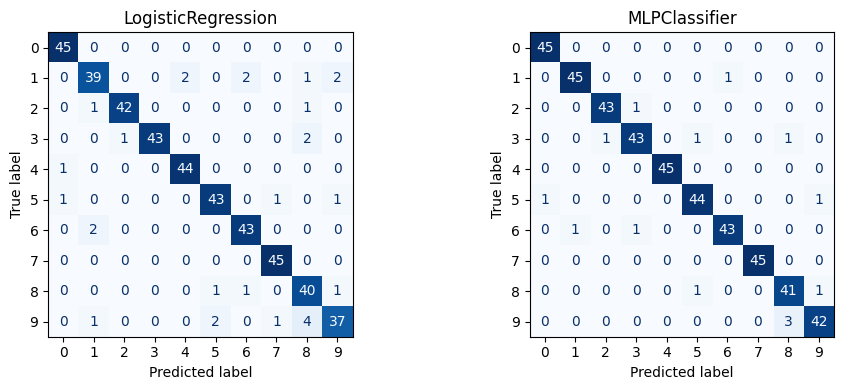

In [4]:
baseline_results = run_default_baseline_suite(digits_split, seed=data_seed)
display_baseline_suite(baseline_results, class_names)

## 3. Standard Superposition Activations

Training 20 epochs (logging every 5)…
  epoch 5/20  train_loss=1.963678
  epoch 10/20  train_loss=1.490329
  epoch 15/20  train_loss=1.120020
  epoch 20/20  train_loss=0.878873
Digits standard superposition activations
  train accuracy = 0.7454
  test accuracy  = 0.7222
  macro-F1       = 0.7125
  tracked units  = [3, 0]
              precision    recall  f1-score   support

           0      0.843     0.956     0.896        45
           1      0.576     0.413     0.481        46
           2      0.854     0.932     0.891        44
           3      0.689     0.674     0.681        46
           4      0.809     0.844     0.826        45
           5      0.696     0.348     0.464        46
           6      0.881     0.822     0.851        45
           7      0.629     0.867     0.729        45
           8      0.566     0.698     0.625        43
           9      0.674     0.689     0.681        45

    accuracy                          0.722       450
   macro avg      0.722    

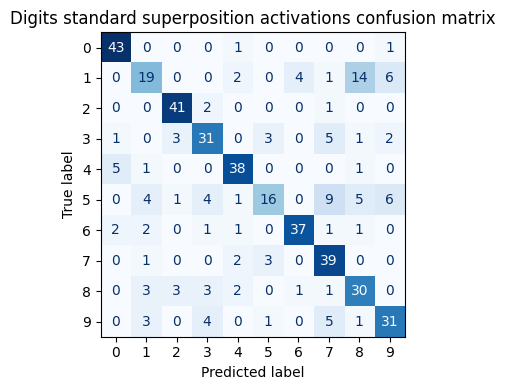

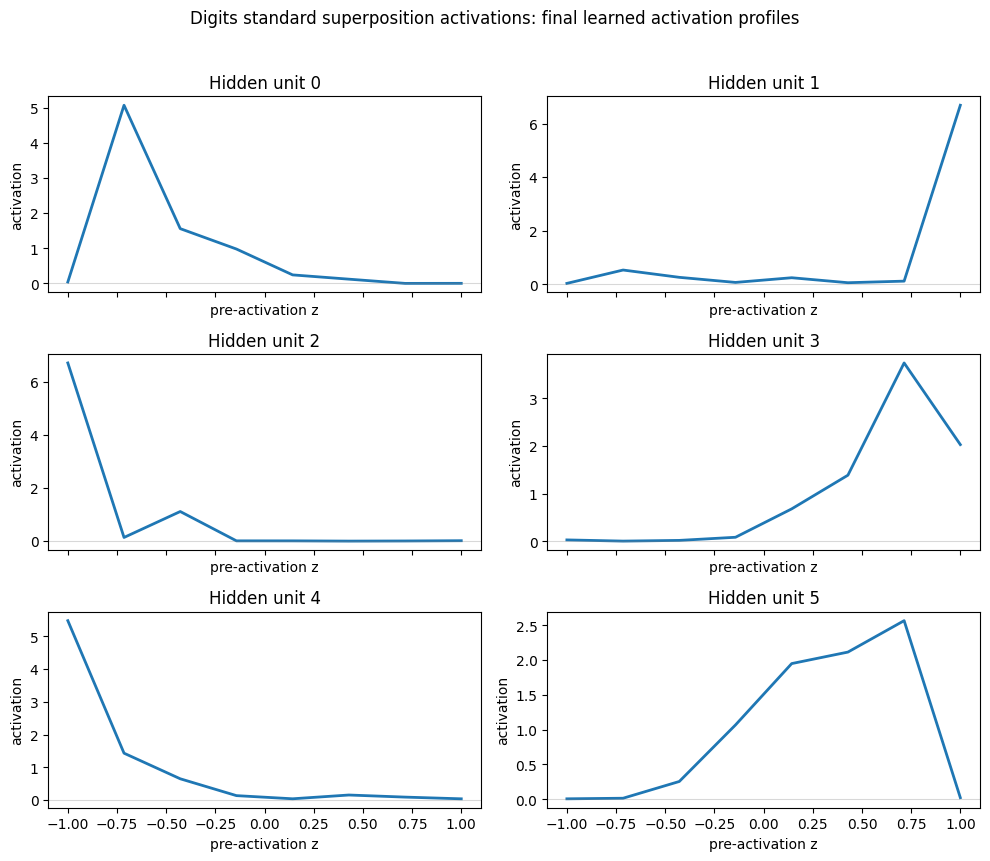

unit 3: exact-vs-measured L1 = 0.194950
unit 0: exact-vs-measured L1 = 0.078752


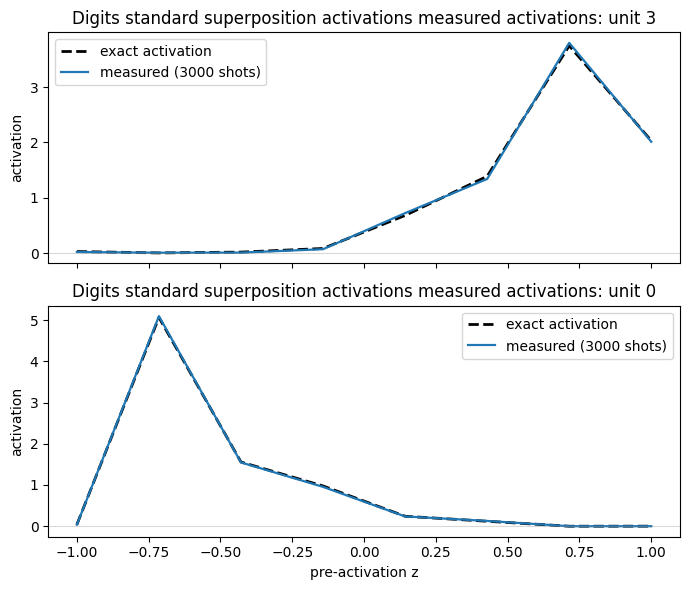

In [5]:
standard_result = run_quantum_experiment(
    "standard",
    label="Digits standard superposition activations",
    split=digits_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
)
display_quantum_result(standard_result, class_names)

### Standard Training Process (Snapshots)

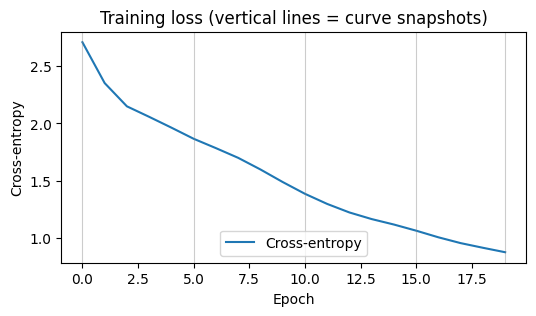

Epoch | loss at snapshot
   -1 | 2.70752
    1 | 2.35177
    3 | 2.0578
    5 | 1.86676
    7 | 1.70082
    9 | 1.49033
   11 | 1.29955
   13 | 1.16753
   15 | 1.06659
   17 | 0.958139
   19 | 0.878873


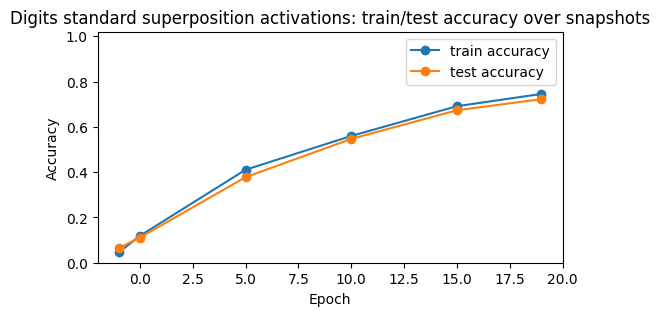

/Users/kooshan/Desktop/QFun/qfun/qfan/_classification_benchmarks.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


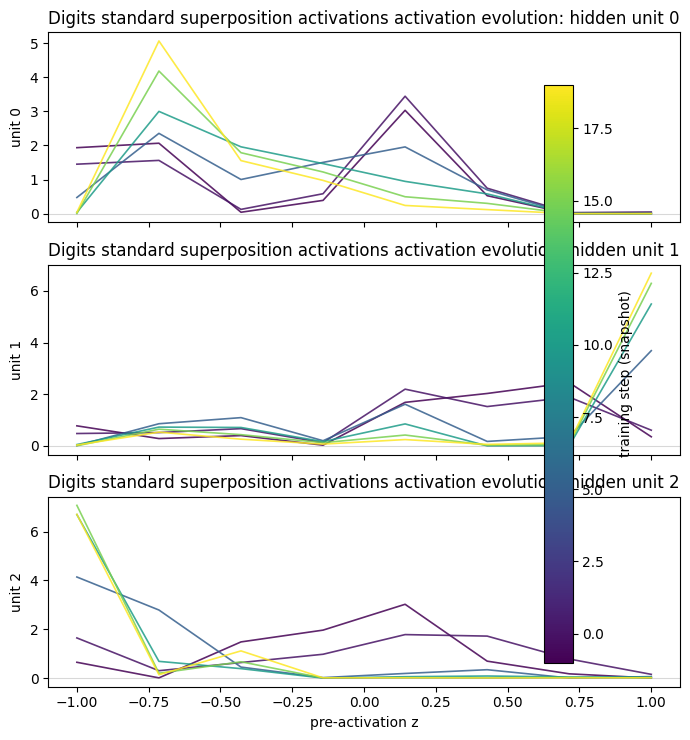

In [6]:
plot_training_diagnostics(standard_result)

## 4. Mode A Signed Superposition Activations

Training 20 epochs (logging every 5)…
  epoch 5/20  train_loss=1.678426
  epoch 10/20  train_loss=1.148861
  epoch 15/20  train_loss=0.853895
  epoch 20/20  train_loss=0.633701
Digits Mode A superposition activations
  train accuracy = 0.8270
  test accuracy  = 0.8067
  macro-F1       = 0.8048
  tracked units  = [3, 1]
              precision    recall  f1-score   support

           0      0.936     0.978     0.957        45
           1      0.733     0.717     0.725        46
           2      0.810     0.773     0.791        44
           3      0.712     0.804     0.755        46
           4      0.925     0.822     0.871        45
           5      0.950     0.826     0.884        46
           6      0.827     0.956     0.887        45
           7      0.741     0.889     0.808        45
           8      0.684     0.605     0.642        43
           9      0.775     0.689     0.729        45

    accuracy                          0.807       450
   macro avg      0.809     0

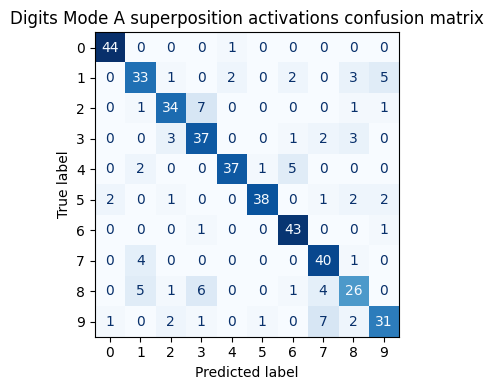

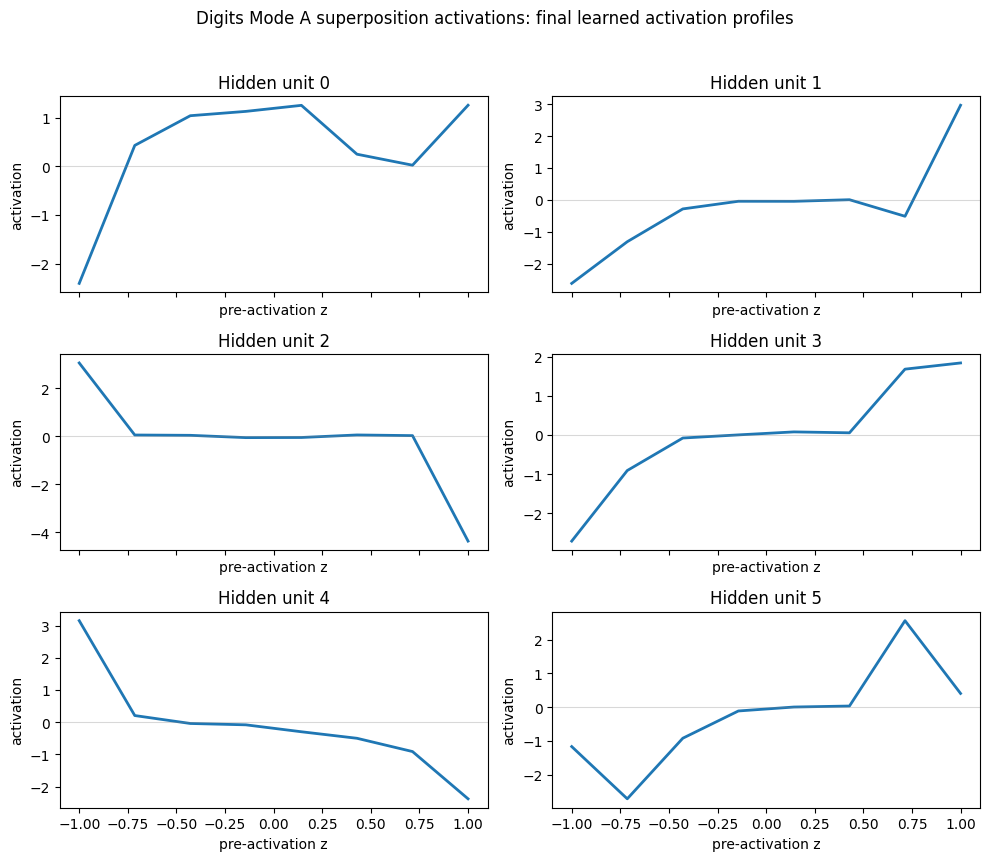

unit 3: exact-vs-measured L1 = 0.116666
  measured p_pos + p_neg = 1.000000
unit 1: exact-vs-measured L1 = 0.270717
  measured p_pos + p_neg = 1.000000


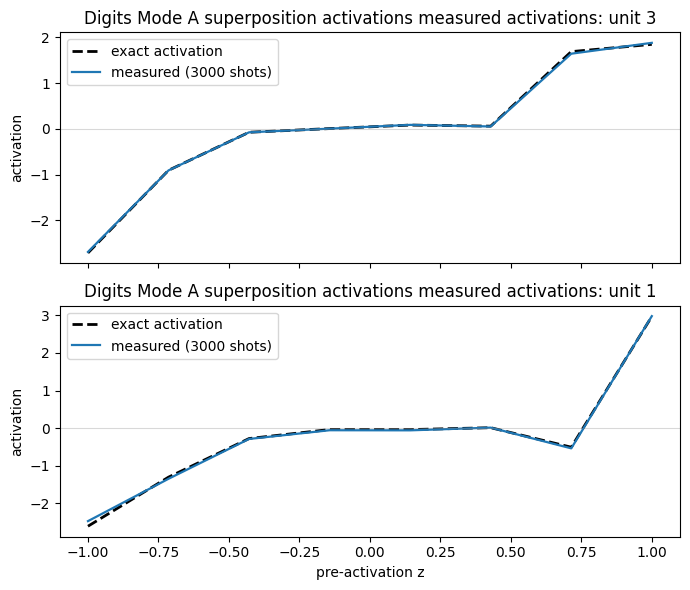

In [7]:
mode_a_result = run_quantum_experiment(
    "mode_a",
    label="Digits Mode A superposition activations",
    split=digits_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
)
display_quantum_result(mode_a_result, class_names)

### Mode A Training Process (Snapshots)

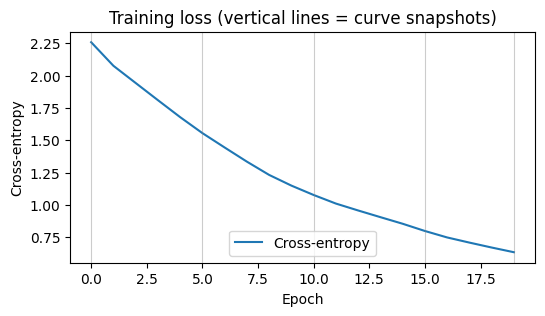

Epoch | loss at snapshot
   -1 | 2.25792
    1 | 2.0756
    3 | 1.80978
    5 | 1.55489
    7 | 1.33418
    9 | 1.14886
   11 | 1.01
   13 | 0.904942
   15 | 0.797945
   17 | 0.708132
   19 | 0.633701


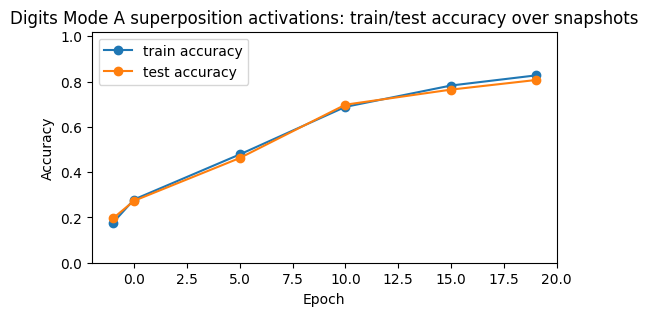

/Users/kooshan/Desktop/QFun/qfun/qfan/_classification_benchmarks.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


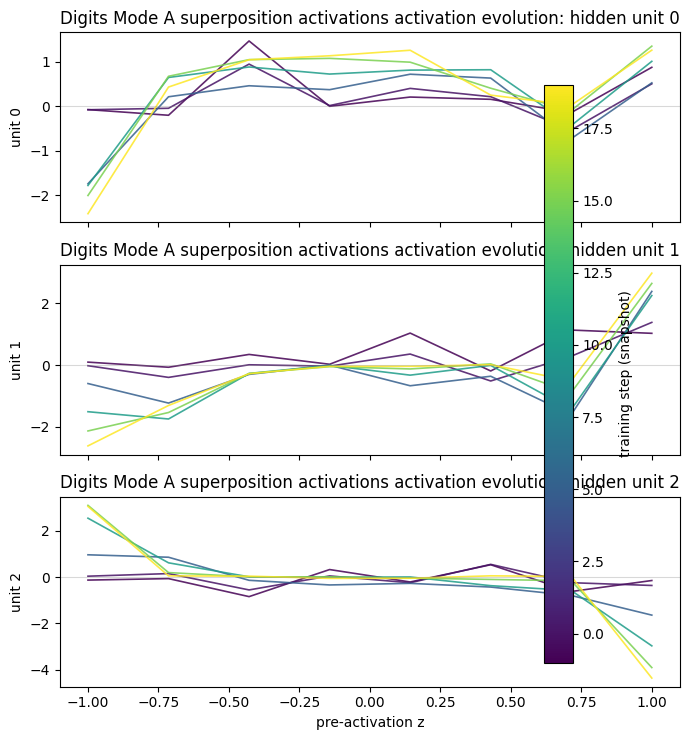

In [8]:
plot_training_diagnostics(mode_a_result)

## 5. Mode B Signed Superposition Activations

Training 20 epochs (logging every 5)…
  epoch 5/20  train_loss=1.618922
  epoch 10/20  train_loss=0.965067
  epoch 15/20  train_loss=0.632469
  epoch 20/20  train_loss=0.449466
Digits Mode B superposition activations
  train accuracy = 0.8641
  test accuracy  = 0.8489
  macro-F1       = 0.8457
  tracked units  = [1, 4]
              precision    recall  f1-score   support

           0      0.880     0.978     0.926        45
           1      0.724     0.913     0.808        46
           2      0.891     0.932     0.911        44
           3      0.860     0.804     0.831        46
           4      0.829     0.756     0.791        45
           5      0.870     0.870     0.870        46
           6      0.952     0.889     0.920        45
           7      0.863     0.978     0.917        45
           8      0.812     0.605     0.693        43
           9      0.829     0.756     0.791        45

    accuracy                          0.849       450
   macro avg      0.851     0

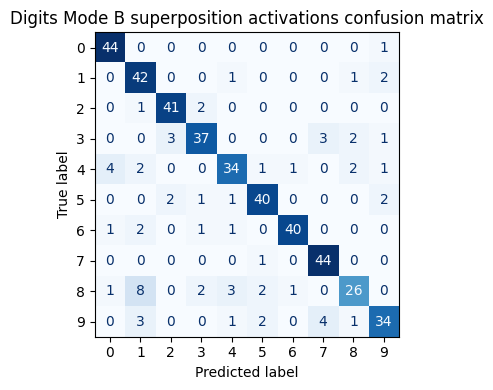

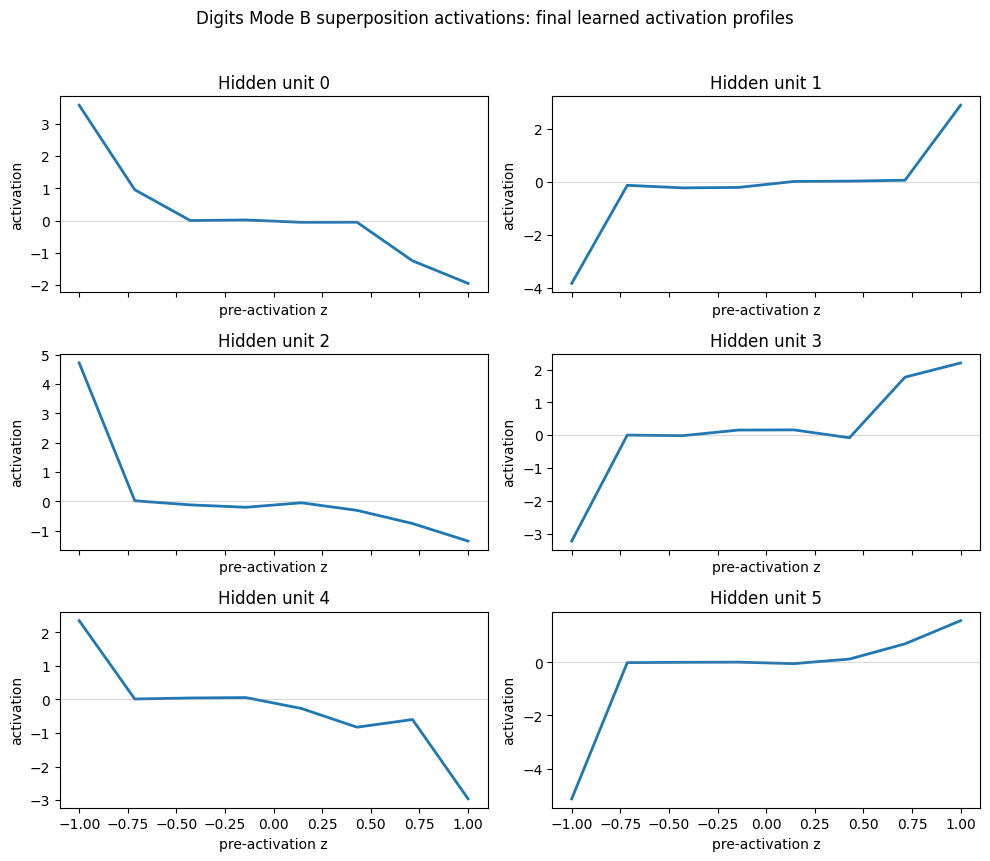

unit 1: exact-vs-measured L1 = 0.124541
  measured z_plus + z_minus = 1.000000
unit 4: exact-vs-measured L1 = 0.120397
  measured z_plus + z_minus = 1.000000


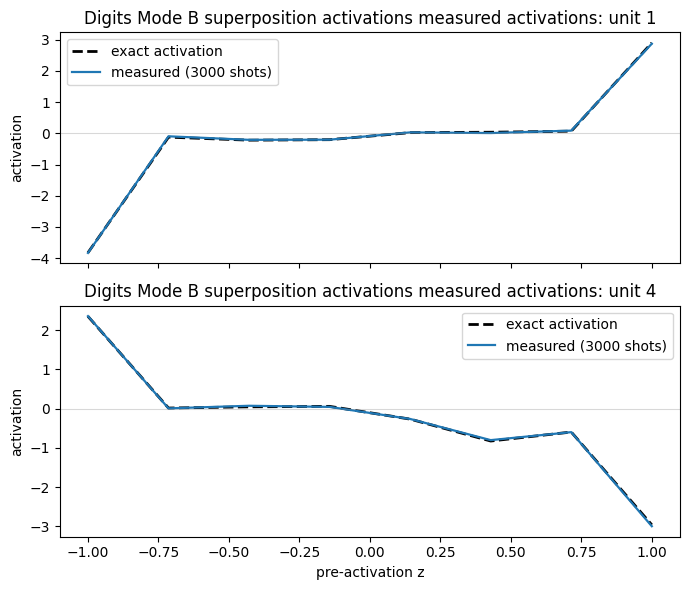

In [9]:
mode_b_result = run_quantum_experiment(
    "mode_b",
    label="Digits Mode B superposition activations",
    split=digits_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
)
display_quantum_result(mode_b_result, class_names)

### Mode B Training Process (Snapshots)

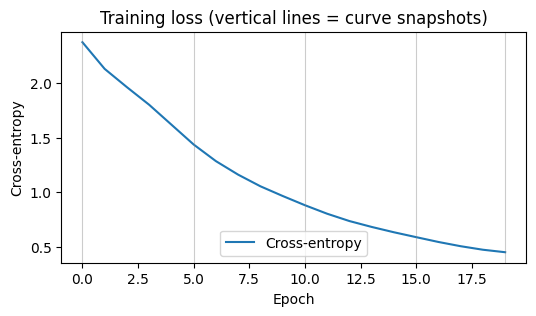

Epoch | loss at snapshot
   -1 | 2.37443
    1 | 2.13001
    3 | 1.80106
    5 | 1.43676
    7 | 1.16039
    9 | 0.965067
   11 | 0.802276
   13 | 0.681318
   15 | 0.587677
   17 | 0.504586
   19 | 0.449466


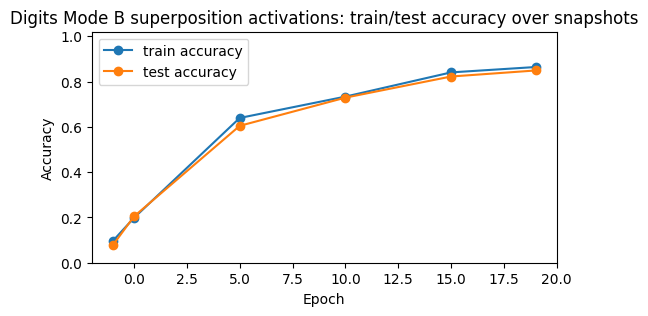

/Users/kooshan/Desktop/QFun/qfun/qfan/_classification_benchmarks.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


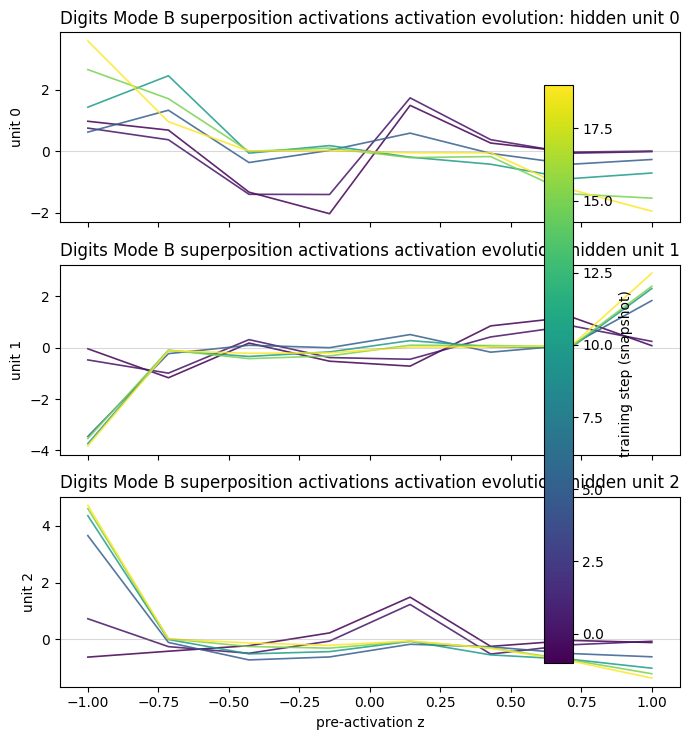

In [10]:
plot_training_diagnostics(mode_b_result)

## 6. Final Comparison

In [11]:
comparison_rows = build_comparison_rows(
    baseline_results,
    [standard_result, mode_a_result, mode_b_result],
)
print_comparison_table(comparison_rows)

Model                                     | Test accuracy | Macro-F1
------------------------------------------+---------------+---------
LogisticRegression                        |        0.9356 |   0.9351
MLPClassifier                             |        0.9689 |   0.9688
Digits standard superposition activations |        0.7222 |   0.7125
Digits Mode A superposition activations   |        0.8067 |   0.8048
Digits Mode B superposition activations   |        0.8489 |   0.8457
